# Time Series Decomposition

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from statsmodels.tsa.seasonal import STL
from scipy.signal import resample


In [8]:
light_curve_dict = joblib.load("5_stars.joblib")
print(light_curve_dict.keys())

# id_per_lst = [(11612280, 9.406136), (7672215, 11.17344), (7811397, 169.497609), (10583181, 2.696355), (8299955, 2.682768)]
# # planets
# t1, vals1, err1 = light_curve_dict[11612280][:3] # 9.406136
# t2, vals2, err2 = light_curve_dict[7672215][:3] # 11.17344
# t3, vals3, err3 = light_curve_dict[7811397][:3] # 169.497609
# # not planets
# t4, vals4, err4 = light_curve_dict[10583181][:3] # 2.696355
# t5, vals5, err5 = light_curve_dict[8299955][:3] # 2.682768

# path ='/home/ashspenc/labs/ACME_VOL3_PLANET_FINDER/GT/cumulative.csv'
# df = pd.read_csv(path, delimiter=',')
# print(df.loc[df['kepid'] == 8299955, 'koi_period'])

dict_keys([11446443, 11414511, 9579641, 10583181, 8299955])


In [9]:

# stl = STL(x_new, period=9.)
# result = stl.fit()

# trend = result.trend
# seasonal = result.seasonal
# residual = result.resid


# plt.subplot(3, 1, 1)
# plt.plot(trend)
# plt.subplot(3, 1, 2)
# plt.plot(seasonal)
# plt.subplot(3, 1, 3)
# plt.plot(residual)
# plt.show()

In [ ]:
def time_series_decomposition(df, estimated_period):
    # ==========================================
    # CLASSICAL DECOMPOSITION
    # ==========================================
    # Estimate Trend
    df = df.set_index('time')
    dt = np.mean(np.diff(df.index))
    window_size = int(estimated_period / dt)
    df['Trend_Estimate'] = df['Original'].rolling(window=window_size, center=True).mean()



    # Seasonality using phase
    df['phase'] = (df.index % estimated_period) / estimated_period

    # Estimate Seasonality (Average the detrended periods)
    df['Detrended'] = df['Original'] - df['Trend_Estimate']

    # group similar positions of the orbit
    num_bins = 20
    df['phase_bin'] = np.floor(df['phase'] * num_bins) / num_bins
    
    # average within each phase bin to reinfors seasonal signal and cancel noise
    unadjusted_seasonality = df.groupby('phase_bin')['Detrended'].mean()
    # center seasonaily with mean zero
    adjusted_seasonality = unadjusted_seasonality - unadjusted_seasonality.mean()

    # takes average seasonal pattern and assigns the correct seasonal values based on phase
    df['Seasonal_Estimate'] = df['phase_bin'].map(adjusted_seasonality)

    # 5. Residuals
    df['Residuals'] = df['Original'] - df['Trend_Estimate'] - df['Seasonal_Estimate']

    # ==========================================
    # STATISTICAL ANALYSIS OF RESIDUALS
    # ==========================================
    # Drop NaNs created by the moving average at the edges
    valid_residuals = df['Residuals'].dropna()
    N = len(valid_residuals)
    res_mean = valid_residuals.mean()

    max_lag = 12
    autocovariances = []
    autocorrelations = []

    # Autocovariance at lag 0 is the variance
    var = np.sum((valid_residuals - res_mean)**2) / N

    for k in range(max_lag + 1):
        if k == 0:
            cov = var
        else:
            # Autocovariance formula
            slice_t = valid_residuals.values[k:] - res_mean
            slice_t_minus_k = valid_residuals.values[:-k] - res_mean
            cov = np.sum(slice_t * slice_t_minus_k) / N
            
        autocovariances.append(cov)
        autocorrelations.append(cov / var) # Autocorrelation

    # ==========================
    # Visualizations
    # ==========================

    fig = plt.figure(figsize=(10, 14))

    # Original vs Trend
    ax1 = plt.subplot(5, 1, 1)
    ax1.plot(df.index, df['Original'], color='gray', marker='o', markersize=4, alpha=0.6, label='Original Data')
    ax1.plot(df.index, df['Trend_Estimate'], color='blue', linewidth=3, label='Estimated Trend')
    ax1.set_title('1. Original Time Series & Trend Estimation', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Detrended Series
    ax2 = plt.subplot(5, 1, 2)
    ax2.plot(df.index, df['Detrended'], color='purple', marker='o', markersize=4)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.set_title('2. Detrended Series (Seasonality + Noise)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Seasonality
    ax3 = plt.subplot(5, 1, 3)
    ax3.plot(df.index, df['Seasonal_Estimate'], color='red', linewidth=2, marker='s')
    ax3.set_title('3. Extracted Seasonal Component', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # Residuals
    ax4 = plt.subplot(5, 1, 4)
    ax4.plot(valid_residuals.index, valid_residuals, color='green', marker='o', linestyle='-', alpha=0.7)
    ax4.axhline(0, color='black', linewidth=2)
    ax4.set_title(f'4. Residuals (Noise) | Mean: {res_mean:.3f}', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # Autocovariance
    ax5 = plt.subplot(5, 2, 9)
    ax5.bar(range(max_lag + 1), autocovariances, color='purple', alpha=0.7)
    ax5.axhline(0, color='black', linewidth=1)
    ax5.set_title('5a. Autocovariance', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Lag (k months)')
    ax5.set_xticks(range(max_lag + 1))
    ax5.grid(True, alpha=0.3)

    # Autocorrelation
    ax6 = plt.subplot(5, 2, 10)
    ax6.stem(range(max_lag + 1), autocorrelations, basefmt="k-")
    conf_int = 2 / np.sqrt(N)
    ax6.axhspan(-conf_int, conf_int, alpha=0.2, color='blue', label='95% Confidence bounds')
    ax6.set_title('5b. Autocorrelation Function', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Lag (k months)')
    ax6.set_xticks(range(max_lag + 1))
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print text summary
    print("===== DIAGNOSTIC SUMMARY =====")
    print(f"Residual Mean (Expected ~0):        {res_mean:.4f}")
    print(f"Residual Variance (Expected ~4):    {autocovariances[0]:.4f}")
    print(f"Autocorrelation Lag 1 (Expected ~0): {autocorrelations[1]:.4f}")

In [11]:
light_curve_dict = joblib.load("5_stars.joblib")
path ='/home/ashspenc/labs/ACME_VOL3_PLANET_FINDER/GT/cumulative.csv'
period_df = pd.read_csv(path, usecols=['kepid', 'koi_period'])
jobids = list(light_curve_dict.keys())


jobids_set = set(jobids)
period_dict = {}

for chunk in pd.read_csv(path, usecols=['kepid', 'koi_period'], chunksize=1000):
    matches = chunk[chunk['kepid'].isin(jobids_set)]
    
    for _, row in matches.iterrows():
        period_dict[int(row['kepid'])] = row['koi_period']

    # Optional: stop early if we've found everything
    if len(period_dict) == len(jobids_set):
        break

11446443


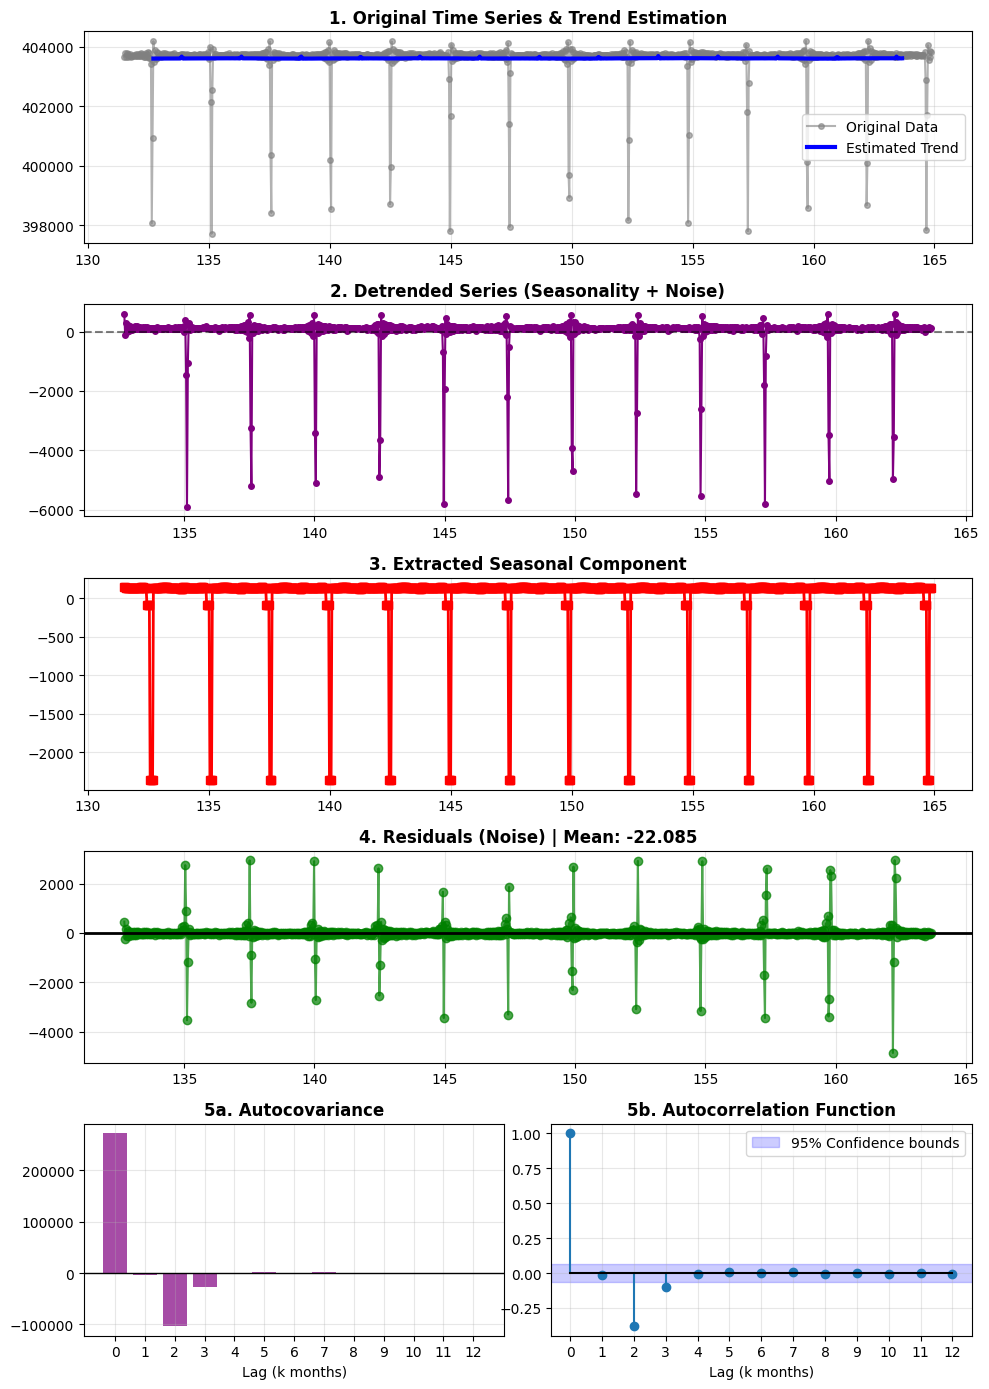

===== DIAGNOSTIC SUMMARY =====
Residual Mean (Expected ~0):        -22.0851
Residual Variance (Expected ~4):    272189.4985
Autocorrelation Lag 1 (Expected ~0): -0.0164
11414511


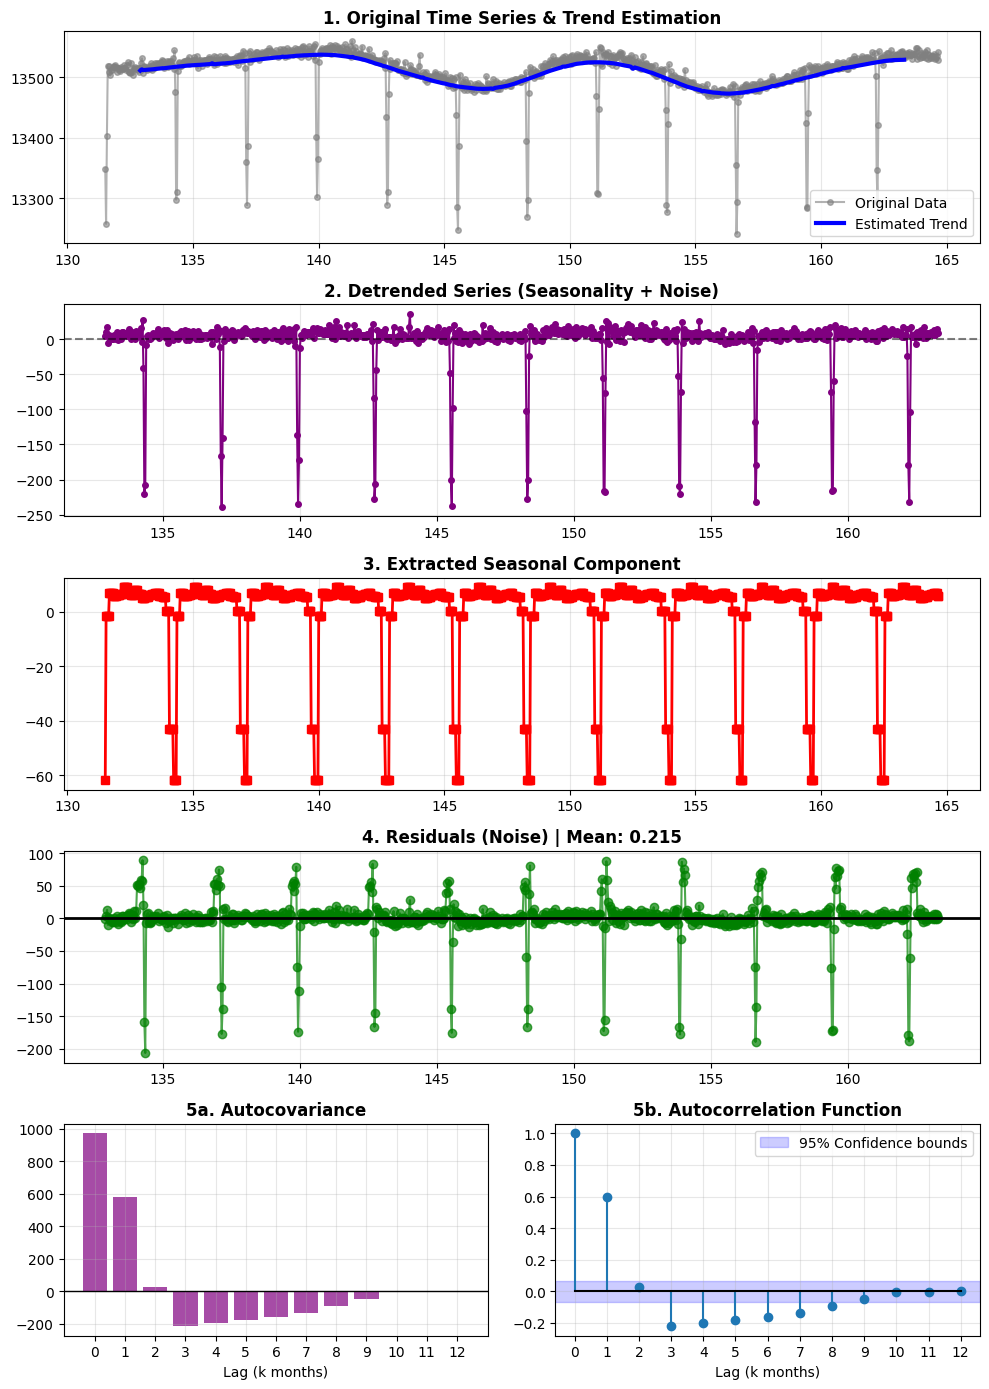

===== DIAGNOSTIC SUMMARY =====
Residual Mean (Expected ~0):        0.2153
Residual Variance (Expected ~4):    971.7733
Autocorrelation Lag 1 (Expected ~0): 0.5975
9579641


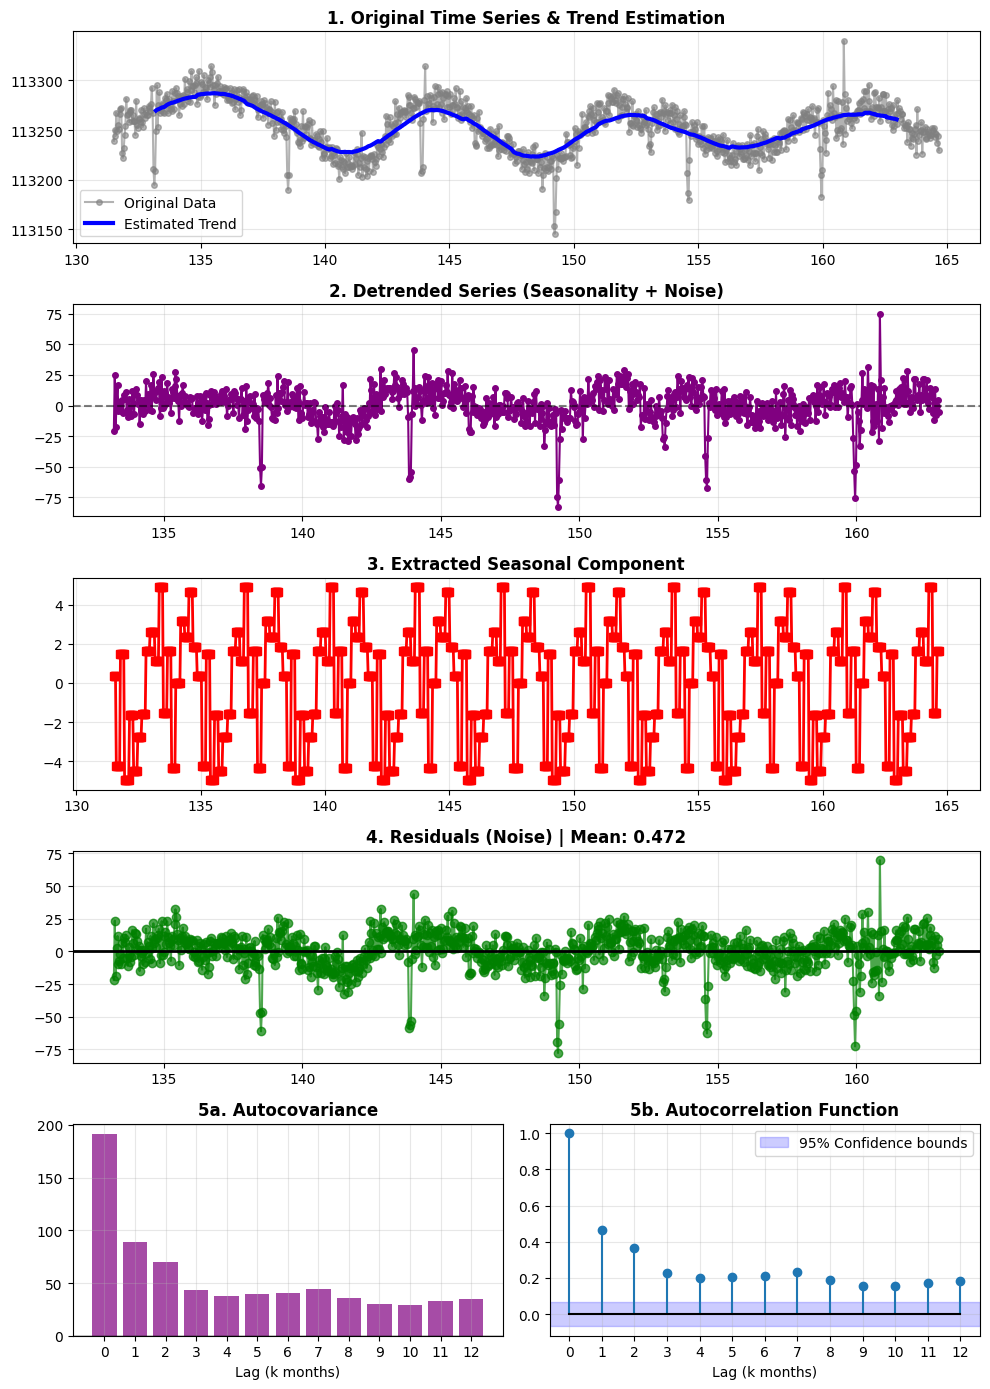

===== DIAGNOSTIC SUMMARY =====
Residual Mean (Expected ~0):        0.4719
Residual Variance (Expected ~4):    191.5351
Autocorrelation Lag 1 (Expected ~0): 0.4632
10583181


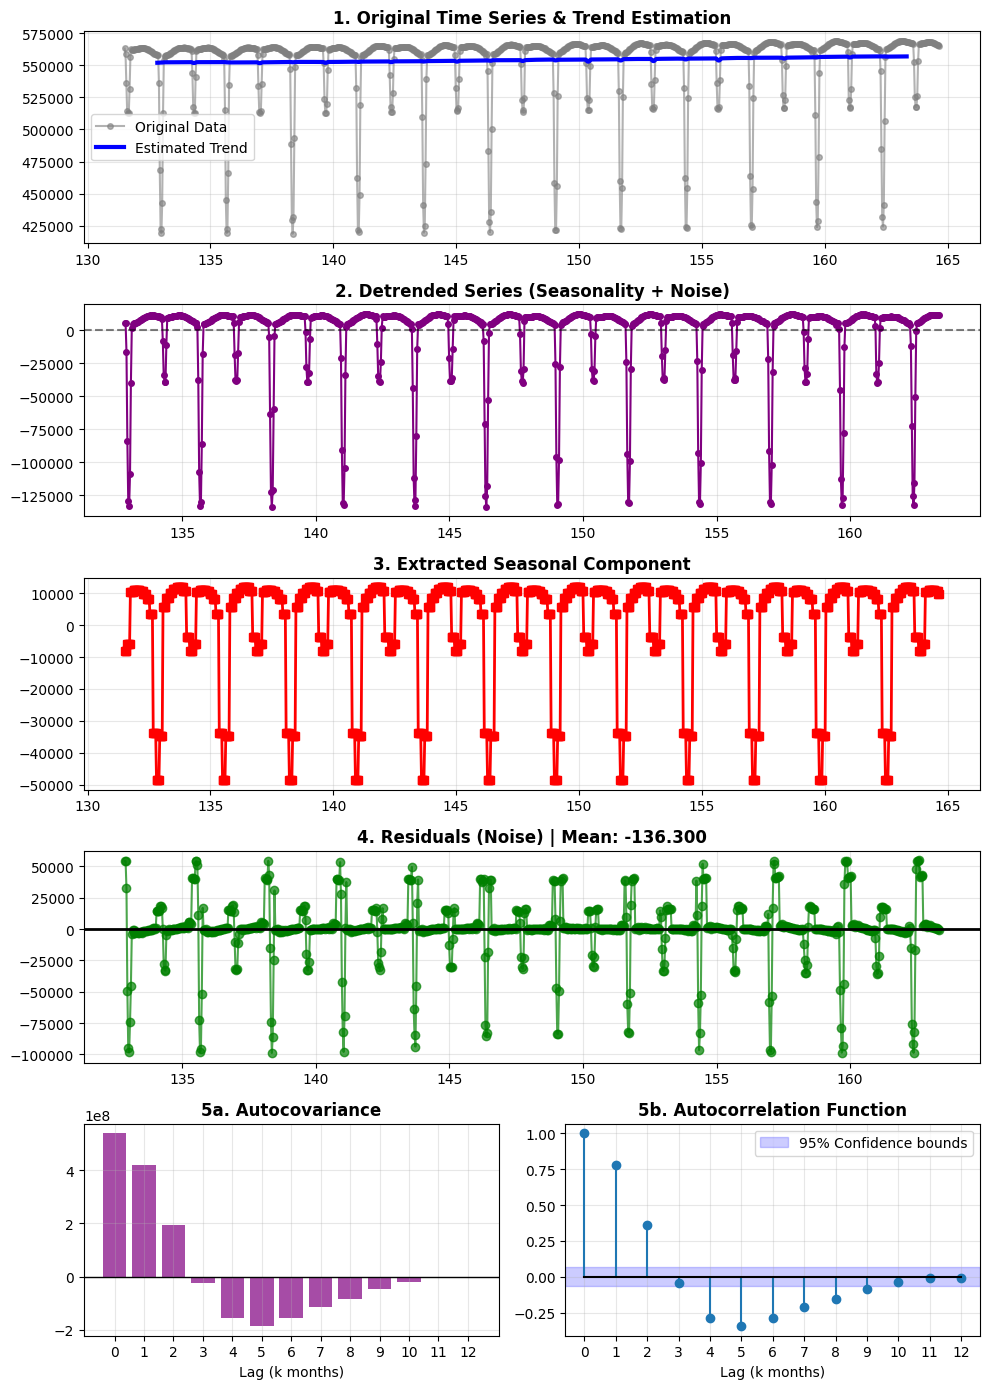

===== DIAGNOSTIC SUMMARY =====
Residual Mean (Expected ~0):        -136.2998
Residual Variance (Expected ~4):    538936370.5558
Autocorrelation Lag 1 (Expected ~0): 0.7800
8299955


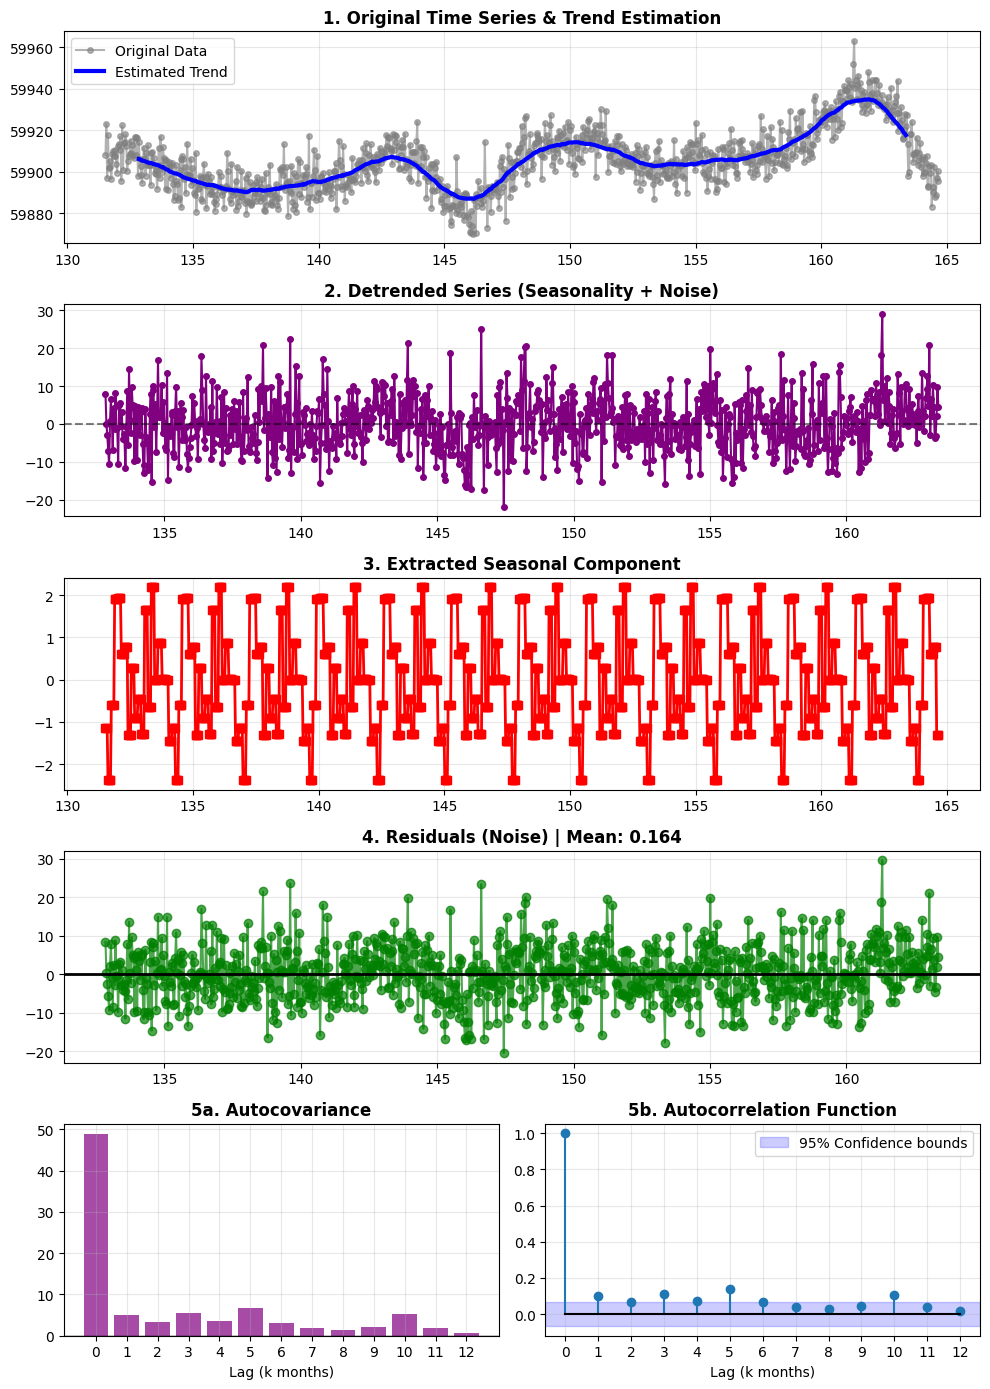

===== DIAGNOSTIC SUMMARY =====
Residual Mean (Expected ~0):        0.1638
Residual Variance (Expected ~4):    48.9151
Autocorrelation Lag 1 (Expected ~0): 0.1025


In [12]:
for jobid in jobids:
    print(jobid)
    period = period_dict[jobid]

    vals = np.asarray(light_curve_dict[jobid]['flux'], dtype=float)
    t = np.asarray(light_curve_dict[jobid]['time'], dtype=float)

    valid_idx = np.where(np.isfinite(vals))[0]
    vals = vals[valid_idx]
    t = t[valid_idx]
    x_new, t_new = resample(vals, 1000, t=t)

    ts_df = pd.DataFrame({
    'time': t_new,
    'Original': x_new})

    time_series_decomposition(ts_df, period)